# vera DETR 평가 노트북
학습이 끝난 가중치를 불러와서 팀 공통 평가 지표로 평가합니다.

In [2]:
# ============================================================
# [Cell 0] 환경 세팅
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, sys

REPO_DIR = '/content/pill_detection_project'
if not os.path.exists(REPO_DIR):
    os.system(f'git clone https://github.com/wina0901/pill_detection_project.git {REPO_DIR}')

sys.path.insert(0, REPO_DIR)

BASE_DIR  = '/content/drive/MyDrive/data/초급_프로젝트/dataset'
EXP_DIR   = '/content/drive/MyDrive/vera_detr/experiments'
VAL_JSON  = f'{BASE_DIR}/val_letterbox.json'

print(f'✅ BASE_DIR : {BASE_DIR}')
print(f'✅ EXP_DIR  : {EXP_DIR}')

Mounted at /content/drive
✅ BASE_DIR : /content/drive/MyDrive/data/초급_프로젝트/dataset
✅ EXP_DIR  : /content/drive/MyDrive/vera_detr/experiments


In [3]:
# ============================================================
# [Cell 1] 패키지 설치
# ============================================================
!pip install transformers timm pycocotools torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.8 MB/s eta 0:00:0000:01


In [4]:
# ============================================================
# [Cell 2] 팀 평가 모듈 import
# ============================================================
from src.evaluation import (
    evaluate_all,
    init_history,
    update_history,
    save_history,
    load_history,
    plot_training_history,
    plot_compare_histories,
)

print('✅ 팀 평가 모듈 로드 완료')

✅ 팀 평가 모듈 로드 완료


In [5]:
# ============================================================
# [Cell 3] Dataset / DataLoader
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import json

class DETRDataset(Dataset):
    def __init__(self, json_path, img_dir, transforms=None):
        with open(json_path, 'r') as f:
            coco = json.load(f)
        self.img_dir    = img_dir
        self.transforms = transforms
        self.images     = {img['id']: img for img in coco['images']}
        cats            = sorted([c['id'] for c in coco['categories']])
        self.cat2idx    = {c: i for i, c in enumerate(cats)}
        self.num_classes = len(cats)
        self.img_ids    = list(self.images.keys())
        self.annots     = {img_id: [] for img_id in self.img_ids}
        for ann in coco['annotations']:
            if ann['image_id'] in self.annots:
                self.annots[ann['image_id']].append(ann)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        img_info = self.images[img_id]
        image    = Image.open(os.path.join(self.img_dir, img_info['file_name'])).convert('RGB')
        W, H     = image.size
        boxes, labels = [], []
        for ann in self.annots[img_id]:
            x, y, w, h = ann['bbox']
            boxes.append([(x+w/2)/W, (y+h/2)/H, w/W, h/H])
            labels.append(self.cat2idx[ann['category_id']])
        target = {
            'boxes':    torch.tensor(boxes,  dtype=torch.float32),
            'labels':   torch.tensor(labels, dtype=torch.long),
            'image_id': torch.tensor([img_id])
        }
        if self.transforms:
            image = self.transforms(image)
        return image, target

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def collate_fn(batch):
    images, targets = zip(*batch)
    return torch.stack(images), list(targets)

val_dataset = DETRDataset(
    json_path=VAL_JSON,
    img_dir=f'{BASE_DIR}/letterbox_images/val',
    transforms=transform
)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False,
                        num_workers=2, collate_fn=collate_fn)

# 역매핑: 0~72 → 원본 category_id
idx2cat = {v: k for k, v in val_dataset.cat2idx.items()}

print(f'✅ val: {len(val_dataset)}장 / 클래스: {val_dataset.num_classes}')

✅ val: 139장 / 클래스: 73


In [6]:
# ============================================================
# [Cell 4] DETR → evaluate_all용 변환 함수
# ============================================================
def convert_detr_outputs(model, loader, device, score_threshold=0.001):
    predictions = []
    model.eval()
    with torch.no_grad():
        for images, targets in loader:
            images  = images.to(device)
            outputs = model(pixel_values=images)
            for i, target in enumerate(targets):
                image_id  = target['image_id'].item()
                W, H      = 800, 800
                logits    = outputs.logits[i]
                boxes     = outputs.pred_boxes[i]
                scores_all = logits.softmax(-1)
                scores, labels = scores_all[:, :-1].max(-1)
                for score, label, box in zip(scores, labels, boxes):
                    score = score.item()
                    if score < score_threshold:
                        continue
                    cx, cy, bw, bh = box.tolist()
                    predictions.append({
                        'image_id':    image_id,
                        'category_id': idx2cat.get(label.item(), label.item()),
                        'bbox_xyxy':   [
                            (cx - bw/2) * W,
                            (cy - bh/2) * H,
                            (cx + bw/2) * W,
                            (cy + bh/2) * H,
                        ],
                        'score': score,
                    })
    return predictions

print('✅ 변환 함수 준비 완료')

✅ 변환 함수 준비 완료


In [7]:
# ============================================================
# [Cell 5] 평가할 실험 목록 확인
# ============================================================
pth_files = [f for f in os.listdir(EXP_DIR) if f.endswith('.pth')]
print('평가 가능한 가중치 목록:')
for f in sorted(pth_files):
    print(f'  - {f}')

평가 가능한 가중치 목록:
  - backbone5e-06_cls5e-05.pth


In [8]:
# ============================================================
# [Cell 6] 실험별 평가 실행
# ============================================================
from transformers import DetrForObjectDetection

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ device: {device}')

all_histories = {}

for pth_file in sorted(pth_files):
    exp_name = pth_file.replace('.pth', '')
    print(f'\n📊 평가 중: {exp_name}')

    # 모델 로드
    model = DetrForObjectDetection.from_pretrained(
        'facebook/detr-resnet-50',
        num_labels=73,
        ignore_mismatched_sizes=True
    )
    model.load_state_dict(torch.load(f'{EXP_DIR}/{pth_file}', map_location=device))
    model.to(device)

    # 예측 변환
    val_predictions = convert_detr_outputs(model, val_loader, device)

    # 팀 공통 평가
    metrics = evaluate_all(
        gt_json_path=VAL_JSON,
        predictions=val_predictions,
        conf_threshold=0.25,
        pr_iou_threshold=0.5,
        temp_json_path=f'detr_temp_{exp_name}.json'
    )

    # train_log 불러와서 history 구성
    log_path = f'{EXP_DIR}/{exp_name}_train_log.json'
    history  = init_history()

    if os.path.exists(log_path):
        with open(log_path) as f:
            log = json.load(f)
        for ep, tl in enumerate(log['train_losses'], 1):
            update_history(history, epoch=ep, train_loss=tl,
                           val_loss=None, metrics=None)

    # 마지막 epoch에 평가 결과 업데이트
    history['mAP@50'][-1]    = metrics['mAP@50']
    history['mAP@75:95'][-1] = metrics['mAP@75:95']
    history['precision'][-1] = metrics['precision']
    history['recall'][-1]    = metrics['recall']

    # 저장
    save_history(history, f'{EXP_DIR}/history_{exp_name}.json')
    all_histories[exp_name] = history

    print(f"  mAP@50    : {metrics['mAP@50']:.4f}")
    print(f"  mAP@75:95 : {metrics['mAP@75:95']:.4f}")
    print(f"  precision : {metrics['precision']:.4f}")
    print(f"  recall    : {metrics['recall']:.4f}")

print('\n✅ 전체 평가 완료!')

✅ device: cuda

📊 평가 중: backbone5e-06_cls5e-05


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.19s).
Accumulating evaluation results...
DONE (t=0.32s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.833
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.856
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.856
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.900
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.832
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.922
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.923
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

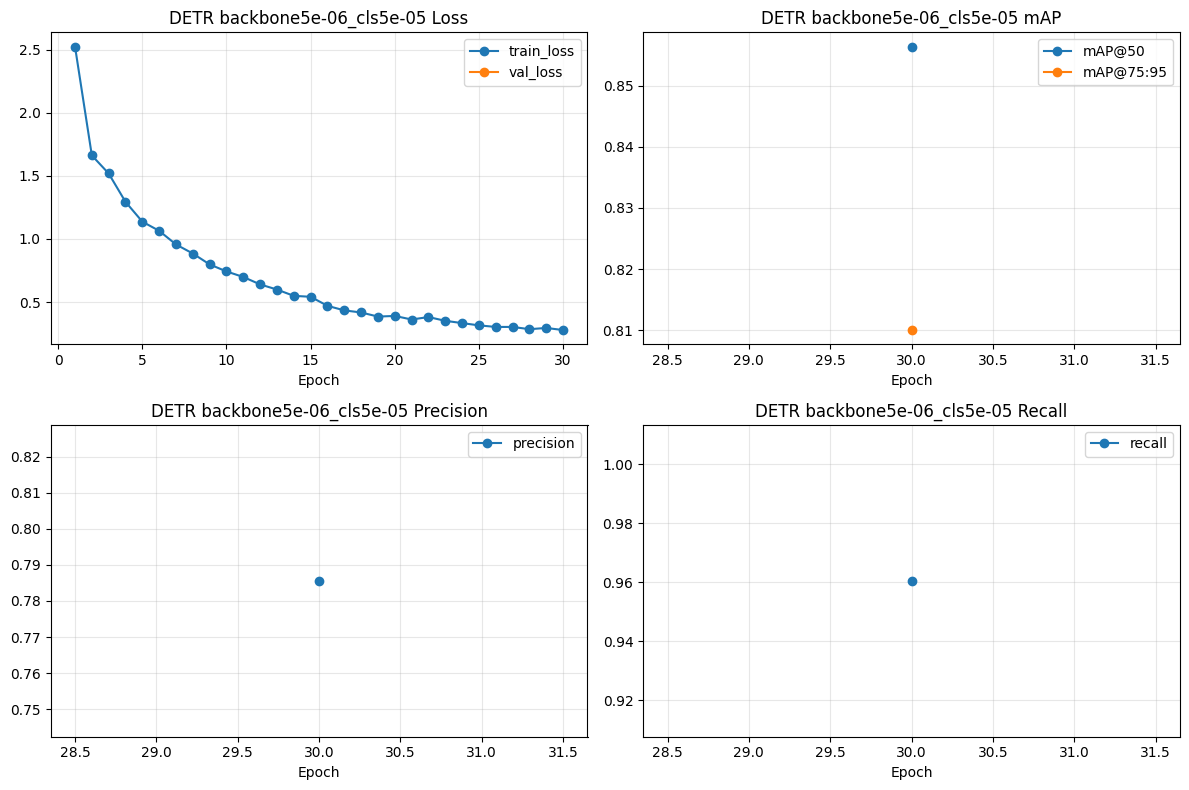

In [9]:
# ============================================================
# [Cell 7] 실험별 시각화
# ============================================================
for exp_name, history in all_histories.items():
    plot_training_history(history, title_prefix=f'DETR {exp_name}')

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


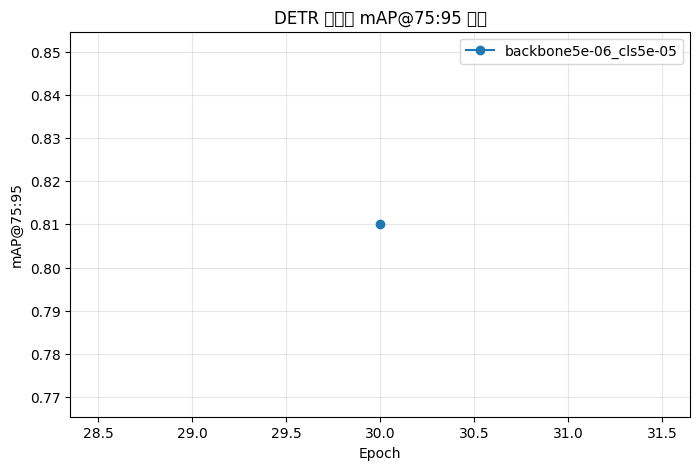

In [10]:
# ============================================================
# [Cell 8] 실험 간 mAP 비교
# ============================================================
histories = list(all_histories.values())
labels    = list(all_histories.keys())

plot_compare_histories(
    histories=histories,
    labels=labels,
    metric_key='mAP@75:95',
    title='DETR 실험별 mAP@75:95 비교'
)